In [51]:
import glob
import pickle as pkl
import matplotlib.pyplot as plt
import numpy as np
import jax.numpy as jnp
from LRUandJaxLIB import *
import os

In [52]:
gloober = [path for path in glob.glob("/root/Project/jax_machinelearning/grid_search26/*") if not os.path.isdir(path)]

best_yet = [0,0]

# Find the best model
for idk, glib in enumerate(gloober):
    with open(glib, "rb") as f:
        res = pkl.load(f)
        if np.max(res["Accuracy Measurements"]["Testing accuracy"]) > best_yet[0]:
            best_yet[0] = np.max(res["Accuracy Measurements"]["Testing accuracy"])
            best_yet[1] = idk
        
with open(gloober[best_yet[1]], "rb") as f:
    dictionary = pkl.load(f)

file_path = dictionary["File Path"]

0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0


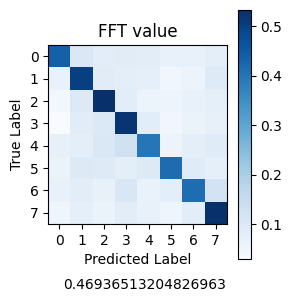

In [53]:
frequnecies = jnp.arange(1, 9, 1)*100+50

with open(file_path, "rb") as f:
    dataset = pkl.load(f)

Confusion_count = np.zeros([8,8])

bins = jnp.stack((frequnecies - 100 / 2, frequnecies + 100 / 2), axis=1)

threshold = 0

for x,y in dataset[:8000]:
    print(y)
    frequency_values = jnp.abs(jnp.fft.fft(x, norm = "ortho"))
    freqs = jnp.fft.fftfreq(len(frequency_values), 1/2000)

    max_frequency = freqs[jnp.argmax(frequency_values)]

    #print(jnp.mean(10*jnp.log10(jnp.delete(frequency_values, jnp.argmax(frequency_values))))+threshold)

    #print(10 * jnp.log10(jnp.max(frequency_values)))

    #10 * jnp.log10(jnp.max(frequency_values)) > jnp.mean(10*jnp.log10(jnp.delete(frequency_values, jnp.argmax(frequency_values))))+threshold:
    # Boolean mask for bins the frequency falls into
    mask = (max_frequency >= bins[:, 0]) & (max_frequency <= bins[:, 1])
    # Find indices of bins
    indices = jnp.where(mask)[0]
    Confusion_count[y,indices] += 1
    # else:
    #     print("Hey")
    #     Confusion_count[y,8] += 1


    
Confusion_matrix = np.zeros([8,8])
for idx, con in enumerate(Confusion_count):
    sum = np.sum(con)
    Confusion_matrix[idx] = con/sum

fig, ax = plt.subplots(figsize = (3,3))

im = ax.imshow(Confusion_matrix, interpolation='nearest', cmap=plt.cm.Blues)
ax.figure.colorbar(im, ax=ax)

ax.set(xticks=np.arange(Confusion_matrix.shape[0]),
    yticks=np.arange(Confusion_matrix.shape[1]),
    xlabel = 'Predicted Label',
        ylabel = 'True Label',
        title = 'Confusion Matrix' )

ax.set_title(f'FFT value')
fig.text(0.50, 0.02,f'{np.trace(Confusion_matrix)/np.sum(Confusion_matrix)}', 
horizontalalignment='center', wrap=True ) 
plt.tight_layout()

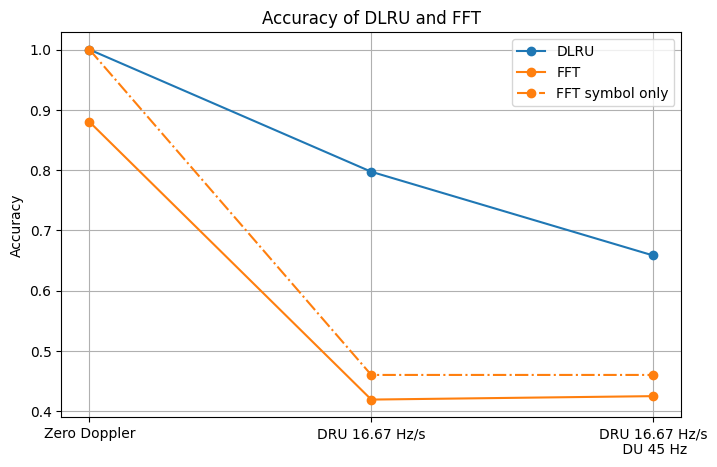

In [65]:
# Signal detection, and symbol detection
acc_of_models = [1, 0.7972, 0.6583]
acc_of_FFT = [0.88, 0.4191, 0.4248]

# Symbol detection only
acc_of_FFT_symbol_detection_only = [1, 0.46, 0.46]

# Example data
categories = ['Zero Doppler', 'DRU 16.67 Hz/s', 'DRU 16.67 Hz/s\n DU 45 Hz']


# Plot
plt.figure(figsize=(8, 5))
plt.plot(categories, acc_of_models, marker='o', linestyle='-', label = "DLRU")
plt.plot(categories, acc_of_FFT, marker='o', linestyle='-', label = "FFT")
plt.plot(categories, acc_of_FFT_symbol_detection_only,color = "tab:orange", marker='o', linestyle='-.', label = "FFT symbol only")
plt.legend()
plt.title('Accuracy of DLRU and FFT')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()
